# Mammoth/CUES Weekly Shortwave + Cloud Binary

This notebook is intentionally minimal.
It loads one week of Mammoth CUES shortwave and does two things:
- plots observed SW vs a clear-sky reference
- derives cloud binary from transmissivity ratio (`obs/ideal`) using a Long & Ackerman-style threshold method.

Window: 2024-06-01 to 2024-08-31 23:59:59
GOES rows in window: 4823
Daytime CUES rows in window: 75881
Matched rows (GOES->nearest CUES): 4786
GOES rule: cloudy if red > 0.00 and green > 0.18

Requested start thresholds:
  clear > 0.85, cloudy < 0.70, n=4156
  acc=0.664, bal_acc=0.589, macro_f1=0.558

Best thresholds from sweep (by macro_f1):
  clear > 0.82, cloudy < 0.60, n=4102
  acc=0.706, bal_acc=0.595, macro_f1=0.580

Top 8 threshold pairs:
 clear_thr  cloudy_thr    n  dropped_ambiguous  accuracy  bal_acc  macro_f1
      0.82        0.60 4102                684  0.705510 0.594787  0.580380
      0.83        0.60 4048                738  0.701828 0.594577  0.578920
      0.82        0.61 4125                661  0.702545 0.594356  0.578778
      0.84        0.60 3998                788  0.698599 0.594583  0.577726
      0.83        0.61 4071                715  0.698845 0.594145  0.577301
      0.84        0.61 4021                765  0.695598 0.594151  0.576089
      0.85        

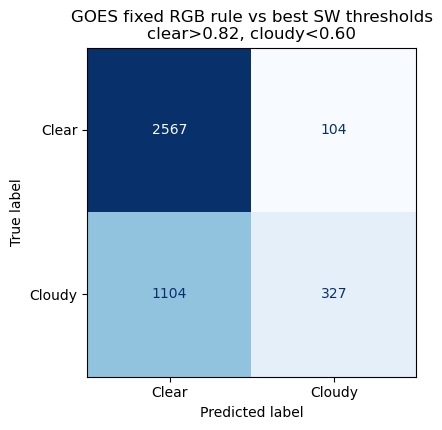

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import xarray as xr
from pathlib import Path
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, accuracy_score, balanced_accuracy_score, f1_score

# ---- Inputs ----
MAMMOTH_CSV = '/glade/u/home/cdalden/goes_work/analysis/output_11b_mammoth/mammoth_rgb_sw_training_table_2024.csv'
CUES_NC = '/glade/u/home/cdalden/goes_work/analysis/CUES_1min_data_atmos_radiation_soiltemp_precip_2015to2025.nc'
CUES_SW_VAR = 'downwelling_shortwave_platform'

# June-August window
WEEK_START = '2024-06-01'  # inclusive
WEEK_END = '2024-09-01'    # exclusive

# Fixed GOES RGB cloud rule requested by user
GOES_RED_THR = 0.00
GOES_GREEN_THR = 0.18

DAYTIME_CLEARSKY_MIN = 20.0
ASOF_TOL_MIN = 3

# Suggested starting point for SW binary
START_CLEAR_THR = 0.85
START_CLOUDY_THR = 0.70

# Sweep ranges for SW binary
CLEAR_GRID = np.round(np.arange(0.82, 0.96, 0.01), 2)
CLOUDY_GRID = np.round(np.arange(0.60, 0.81, 0.01), 2)

def _score(y_true, y_pred):
    if len(y_true) == 0:
        return np.nan, np.nan, np.nan
    acc = accuracy_score(y_true, y_pred)
    if len(np.unique(y_true)) > 1:
        bacc = balanced_accuracy_score(y_true, y_pred)
        mf1 = f1_score(y_true, y_pred, average='macro')
    else:
        bacc = np.nan
        mf1 = np.nan
    return acc, bacc, mf1

# ---- Load Mammoth GOES RGB (5-min) ----
goes = pd.read_csv(MAMMOTH_CSV, parse_dates=['time'])
goes['time'] = pd.to_datetime(goes['time'], errors='coerce').astype('datetime64[ns]')
goes = goes[(goes['time'] >= pd.Timestamp(WEEK_START)) & (goes['time'] < pd.Timestamp(WEEK_END))].copy()
goes = goes.dropna(subset=['time', 'red', 'green']).copy()
goes = (
    goes.groupby('time', as_index=False)
        .agg(red=('red', 'mean'), green=('green', 'mean'))
        .sort_values('time')
        .reset_index(drop=True)
)
goes['time'] = pd.to_datetime(goes['time'], errors='coerce').astype('datetime64[ns]')

# Fixed rule: cloudy if red > 0 and green > 0.18
goes['goes_cloud_binary'] = ((goes['red'] > GOES_RED_THR) & (goes['green'] > GOES_GREEN_THR)).astype(int)

# ---- Build CUES 1-min transmissivity series ----
p = Path(CUES_NC)
if not p.exists():
    raise FileNotFoundError(f'File not found: {CUES_NC}')

with xr.open_dataset(CUES_NC, decode_times=True) as ds:
    if CUES_SW_VAR not in ds.variables:
        raise KeyError(f'{CUES_SW_VAR} not found in {CUES_NC}')
    tname = None
    for cand in ['time', 'datetime']:
        if cand in ds.coords or cand in ds.variables:
            tname = cand
            break
    if tname is None:
        raise KeyError('No time coordinate found in CUES file.')
    cues = pd.DataFrame({
        'time': pd.to_datetime(ds[tname].values, errors='coerce'),
        'obs_sw': pd.to_numeric(ds[CUES_SW_VAR].values, errors='coerce'),
    })

cues['time'] = pd.to_datetime(cues['time'], errors='coerce').astype('datetime64[ns]')
cues = cues.dropna(subset=['time', 'obs_sw']).sort_values('time').reset_index(drop=True)
cues = cues[(cues['time'] >= pd.Timestamp(WEEK_START)) & (cues['time'] < pd.Timestamp(WEEK_END))].copy()
cues = cues[cues['obs_sw'] >= 0].copy()
if cues.empty:
    raise ValueError('No CUES SW data in selected window.')

cues['minute_of_day'] = cues['time'].dt.hour * 60 + cues['time'].dt.minute
cs_ref = (
    cues.groupby('minute_of_day')['obs_sw']
        .quantile(0.95)
        .rename('clear_sky_sw_ref')
        .reset_index()
        .sort_values('minute_of_day')
)
cues = cues.merge(cs_ref, on='minute_of_day', how='left')

with np.errstate(divide='ignore', invalid='ignore'):
    cues['tau_sw'] = np.where(cues['clear_sky_sw_ref'] > 0, cues['obs_sw'] / cues['clear_sky_sw_ref'], np.nan)

day_mask = cues['clear_sky_sw_ref'] >= DAYTIME_CLEARSKY_MIN
cues = cues[day_mask].copy()
cues = cues[['time', 'tau_sw']].sort_values('time').reset_index(drop=True)

# ---- Match GOES to nearest daytime CUES point once ----
matched = pd.merge_asof(
    goes[['time', 'goes_cloud_binary']].sort_values('time'),
    cues[['time', 'tau_sw']].sort_values('time'),
    on='time',
    direction='nearest',
    tolerance=pd.Timedelta(minutes=ASOF_TOL_MIN),
)
matched = matched.dropna(subset=['tau_sw']).copy()

# ---- Sweep SW thresholds for CUES cloud binary ----
rows = []
for clear_thr in CLEAR_GRID:
    for cloudy_thr in CLOUDY_GRID:
        if cloudy_thr >= clear_thr:
            continue

        tmp = matched.copy()
        tmp['cues_cloud_binary'] = np.nan
        tmp.loc[tmp['tau_sw'] > clear_thr, 'cues_cloud_binary'] = 0
        tmp.loc[tmp['tau_sw'] < cloudy_thr, 'cues_cloud_binary'] = 1
        tmp = tmp.dropna(subset=['cues_cloud_binary']).copy()
        if tmp.empty:
            continue
        tmp['cues_cloud_binary'] = tmp['cues_cloud_binary'].astype(int)

        y_true = tmp['cues_cloud_binary'].to_numpy()
        y_pred = tmp['goes_cloud_binary'].to_numpy()
        acc, bacc, mf1 = _score(y_true, y_pred)

        rows.append({
            'clear_thr': clear_thr,
            'cloudy_thr': cloudy_thr,
            'n': len(tmp),
            'dropped_ambiguous': len(matched) - len(tmp),
            'accuracy': acc,
            'bal_acc': bacc,
            'macro_f1': mf1,
        })

res = pd.DataFrame(rows).sort_values(['macro_f1', 'bal_acc', 'accuracy'], ascending=False).reset_index(drop=True)
if res.empty:
    raise ValueError('No valid threshold combinations produced classified matches.')

# Evaluate requested starting pair
start_tmp = matched.copy()
start_tmp['cues_cloud_binary'] = np.nan
start_tmp.loc[start_tmp['tau_sw'] > START_CLEAR_THR, 'cues_cloud_binary'] = 0
start_tmp.loc[start_tmp['tau_sw'] < START_CLOUDY_THR, 'cues_cloud_binary'] = 1
start_tmp = start_tmp.dropna(subset=['cues_cloud_binary']).copy()
start_tmp['cues_cloud_binary'] = start_tmp['cues_cloud_binary'].astype(int)
s_acc, s_bacc, s_mf1 = _score(start_tmp['cues_cloud_binary'].to_numpy(), start_tmp['goes_cloud_binary'].to_numpy())

best = res.iloc[0]
best_clear = float(best['clear_thr'])
best_cloudy = float(best['cloudy_thr'])

best_tmp = matched.copy()
best_tmp['cues_cloud_binary'] = np.nan
best_tmp.loc[best_tmp['tau_sw'] > best_clear, 'cues_cloud_binary'] = 0
best_tmp.loc[best_tmp['tau_sw'] < best_cloudy, 'cues_cloud_binary'] = 1
best_tmp = best_tmp.dropna(subset=['cues_cloud_binary']).copy()
best_tmp['cues_cloud_binary'] = best_tmp['cues_cloud_binary'].astype(int)

y_true_best = best_tmp['cues_cloud_binary'].to_numpy()
y_pred_best = best_tmp['goes_cloud_binary'].to_numpy()
cm = confusion_matrix(y_true_best, y_pred_best, labels=[0, 1])

print(f'Window: {WEEK_START} to {pd.Timestamp(WEEK_END) - pd.Timedelta(seconds=1)}')
print(f'GOES rows in window: {len(goes)}')
print(f'Daytime CUES rows in window: {len(cues)}')
print(f'Matched rows (GOES->nearest CUES): {len(matched)}')
print(f'GOES rule: cloudy if red > {GOES_RED_THR:.2f} and green > {GOES_GREEN_THR:.2f}')

print('\nRequested start thresholds:')
print(f'  clear > {START_CLEAR_THR:.2f}, cloudy < {START_CLOUDY_THR:.2f}, n={len(start_tmp)}')
print(f'  acc={s_acc:.3f}, bal_acc={s_bacc:.3f}, macro_f1={s_mf1:.3f}')

print('\nBest thresholds from sweep (by macro_f1):')
print(f'  clear > {best_clear:.2f}, cloudy < {best_cloudy:.2f}, n={int(best["n"])}')
print(f'  acc={best["accuracy"]:.3f}, bal_acc={best["bal_acc"]:.3f}, macro_f1={best["macro_f1"]:.3f}')

print('\nTop 8 threshold pairs:')
print(res[['clear_thr', 'cloudy_thr', 'n', 'dropped_ambiguous', 'accuracy', 'bal_acc', 'macro_f1']].head(8).to_string(index=False))

fig, ax = plt.subplots(figsize=(4.8, 4.4))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Clear', 'Cloudy'])
disp.plot(ax=ax, cmap='Blues', colorbar=False, values_format='d')
ax.set_title(f'GOES fixed RGB rule vs best SW thresholds\nclear>{best_clear:.2f}, cloudy<{best_cloudy:.2f}')
plt.tight_layout()
plt.show()

Jun-Aug rows used: 4823
Class counts (0=clear,1=cloudy): {0: 1900, 1: 2923}
accuracy=0.935, bal_acc=0.931, macro_f1=0.932

Classification report:
              precision    recall  f1-score   support

       Clear      0.925     0.909     0.917       475
      Cloudy      0.942     0.952     0.947       731

    accuracy                          0.935      1206
   macro avg      0.933     0.931     0.932      1206
weighted avg      0.935     0.935     0.935      1206

Decision tree rules:
|--- blue <= 0.08
|   |--- green <= 0.05
|   |   |--- class: 0
|   |--- green >  0.05
|   |   |--- class: 0
|--- blue >  0.08
|   |--- red <= 0.01
|   |   |--- class: 1
|   |--- red >  0.01
|   |   |--- class: 1



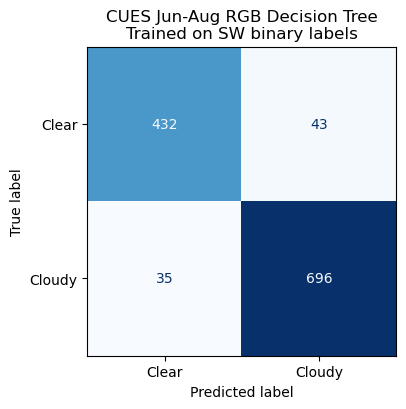

In [26]:
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, export_text
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay, accuracy_score, balanced_accuracy_score, f1_score

# Train a fresh CUES-specific RGB -> SW-binary decision tree for Jun-Aug.
cues_train = pd.read_csv(MAMMOTH_CSV, parse_dates=['time'])
cues_train['time'] = pd.to_datetime(cues_train['time'], errors='coerce').astype('datetime64[ns]')

required_cols = {'time', 'red', 'green', 'blue', 'cloud_binary'}
missing = required_cols - set(cues_train.columns)
if missing:
    raise KeyError(f'Missing required columns in {MAMMOTH_CSV}: {sorted(missing)}')

cues_train = cues_train[
    (cues_train['time'] >= pd.Timestamp(WEEK_START))
    & (cues_train['time'] < pd.Timestamp(WEEK_END))
].copy()

cues_train = cues_train.dropna(subset=['red', 'green', 'blue', 'cloud_binary']).copy()
cues_train['cloud_binary'] = cues_train['cloud_binary'].astype(int)

X = cues_train[['red', 'green', 'blue']]
y = cues_train['cloud_binary']

if y.nunique() < 2:
    raise ValueError('Only one class present in SW binary labels for selected window.')

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.25,
    random_state=42,
    stratify=y,
)

cues_tree = DecisionTreeClassifier(
    max_depth=2,
    min_samples_split=20,
    class_weight='balanced',
    random_state=42,
)
cues_tree.fit(X_train, y_train)

y_pred = cues_tree.predict(X_test)

acc = accuracy_score(y_test, y_pred)
bacc = balanced_accuracy_score(y_test, y_pred)
mf1 = f1_score(y_test, y_pred, average='macro')

print(f'Jun-Aug rows used: {len(cues_train)}')
print('Class counts (0=clear,1=cloudy):', y.value_counts().sort_index().to_dict())
print(f'accuracy={acc:.3f}, bal_acc={bacc:.3f}, macro_f1={mf1:.3f}')
print('\nClassification report:')
print(classification_report(y_test, y_pred, target_names=['Clear', 'Cloudy'], digits=3, zero_division=0))

print('Decision tree rules:')
print(export_text(cues_tree, feature_names=['red', 'green', 'blue']))

cm = confusion_matrix(y_test, y_pred, labels=[0, 1])
fig, ax = plt.subplots(figsize=(4.8, 4.2))
ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Clear', 'Cloudy']).plot(
    ax=ax,
    cmap='Blues',
    colorbar=False,
    values_format='d',
)
ax.set_title('CUES Jun-Aug RGB Decision Tree\nTrained on SW binary labels')
plt.tight_layout()
plt.show()

In [27]:
# Quick environment probe for available Gothic inputs in current kernel/workspace.
from pathlib import Path
import pprint

print('Has SITES:', 'SITES' in globals())
if 'SITES' in globals():
    print('SITES keys:', list(SITES.keys()))
    pprint.pprint(SITES)

for name in ['GOTHIC_RGB_DIR', 'OUT_DIR', 'THRESH_CSV', 'TEMP_BIN_THRESH_CSV', 'GLOBAL_THRESH_CSV', 'MAMMOTH_CSV']:
    if name in globals():
        print(name, '=', globals()[name])

cands = [
    '/glade/u/home/cdalden/goes_work/analysis/output_12_rgb_threshold_transfer/gothic_threshold_transfer_all_rules.csv',
    '/glade/u/home/cdalden/goes_work/analysis/output_12_rgb_threshold_transfer/gothic_rgb_band_thresholds.csv',
    '/glade/u/home/cdalden/goes_work/analysis/output_12_rgb_threshold_transfer/gothic_temp_bin_rgb_thresholds.csv',
]
for p in cands:
    print(Path(p), 'exists=', Path(p).exists())

Has SITES: True
SITES keys: ['mammoth', 'senator_beck']
{'mammoth': '/glade/u/home/cdalden/goes_work/analysis/output_11b_mammoth/mammoth_rgb_sw_training_table_2024.csv',
 'senator_beck': '/glade/u/home/cdalden/goes_work/analysis/output_11c_senator_beck/senator_beck_rgb_sw_training_table_2024.csv'}
GOTHIC_RGB_DIR = /glade/u/home/cdalden/scratch/colorado/goes16/east_river_cloud_binary
OUT_DIR = /glade/u/home/cdalden/goes_work/analysis/output_12_rgb_threshold_transfer
THRESH_CSV = /glade/u/home/cdalden/goes_work/analysis/output_12_rgb_threshold_transfer/gothic_rgb_band_thresholds.csv
TEMP_BIN_THRESH_CSV = /glade/u/home/cdalden/goes_work/analysis/output_12_rgb_threshold_transfer/gothic_temp_bin_rgb_thresholds.csv
GLOBAL_THRESH_CSV = /glade/u/home/cdalden/goes_work/analysis/output_12_rgb_threshold_transfer/gothic_rgb_band_thresholds.csv
MAMMOTH_CSV = /glade/u/home/cdalden/goes_work/analysis/output_11b_mammoth/mammoth_rgb_sw_training_table_2024.csv
/glade/u/home/cdalden/goes_work/analysis/ou

In [28]:
from pathlib import Path
from glob import glob

# Refit Gothic RGB thresholds using only summer months (Jun-Aug).
gothic_files = sorted(glob(str(Path(GOTHIC_RGB_DIR) / 'east_river_cloud_binary_*.csv')))
if not gothic_files:
    raise FileNotFoundError(f'No Gothic cloud-binary files found in {GOTHIC_RGB_DIR}')

gothic_rows = []
for f in gothic_files:
    d = pd.read_csv(f)
    if 'time' not in d.columns:
        continue
    d['time'] = pd.to_datetime(d['time'], errors='coerce').astype('datetime64[ns]')
    d = d.dropna(subset=['time'])
    d = d[d['time'].dt.month.isin([6, 7, 8])].copy()
    if d.empty:
        continue
    gothic_rows.append(d)

if not gothic_rows:
    raise ValueError('No Gothic Jun-Aug rows found in source files.')

gothic_summer = pd.concat(gothic_rows, ignore_index=True)
gothic_summer = gothic_summer.dropna(subset=['red', 'green', 'blue', 'cloud_binary']).copy()
gothic_summer['cloud_binary'] = gothic_summer['cloud_binary'].astype(int)

# Keep 5-min unique timestamps.
gothic_summer = (
    gothic_summer.sort_values('time')
    .drop_duplicates(subset=['time'])
    .reset_index(drop=True)
)

if gothic_summer['cloud_binary'].nunique() < 2:
    raise ValueError('Gothic summer data has only one class after filtering.')

def _best_threshold(values, y_true):
    vals = np.asarray(values, dtype=float)
    y = np.asarray(y_true, dtype=int)

    cands = np.unique(vals[np.isfinite(vals)])
    if len(cands) > 2000:
        qs = np.linspace(0.01, 0.99, 199)
        cands = np.unique(np.quantile(cands, qs))

    best = None
    for direction in ('>', '<='):
        for thr in cands:
            if direction == '>':
                pred = (vals > thr).astype(int)
            else:
                pred = (vals <= thr).astype(int)

            tp = np.sum((pred == 1) & (y == 1))
            fn = np.sum((pred == 0) & (y == 1))
            tn = np.sum((pred == 0) & (y == 0))
            fp = np.sum((pred == 1) & (y == 0))

            tpr = tp / (tp + fn) if (tp + fn) else np.nan
            tnr = tn / (tn + fp) if (tn + fp) else np.nan
            if np.isnan(tpr) or np.isnan(tnr):
                continue
            youden = tpr + tnr - 1

            if (best is None) or (youden > best['youden_j']):
                best = {
                    'threshold': float(thr),
                    'direction': direction,
                    'youden_j': float(youden),
                }

    return best

band_thresholds = {}
for band in ['red', 'green', 'blue']:
    best = _best_threshold(gothic_summer[band].to_numpy(), gothic_summer['cloud_binary'].to_numpy())
    if best is None:
        raise ValueError(f'Could not find threshold for band: {band}')
    band_thresholds[band] = best

# Apply thresholds to produce rule-based cloud predictions.
for band in ['red', 'green', 'blue']:
    thr = band_thresholds[band]['threshold']
    direction = band_thresholds[band]['direction']
    if direction == '>':
        gothic_summer[f'vote_{band}'] = (gothic_summer[band] > thr).astype(int)
    else:
        gothic_summer[f'vote_{band}'] = (gothic_summer[band] <= thr).astype(int)

votes = gothic_summer[['vote_red', 'vote_green', 'vote_blue']].sum(axis=1)
gothic_summer['pred_union'] = (votes >= 1).astype(int)
gothic_summer['pred_majority'] = (votes >= 2).astype(int)
gothic_summer['pred_intersection'] = (votes == 3).astype(int)

def _metrics(y_true, y_pred):
    y_t = np.asarray(y_true, dtype=int)
    y_p = np.asarray(y_pred, dtype=int)

    tp = int(np.sum((y_p == 1) & (y_t == 1)))
    fn = int(np.sum((y_p == 0) & (y_t == 1)))
    tn = int(np.sum((y_p == 0) & (y_t == 0)))
    fp = int(np.sum((y_p == 1) & (y_t == 0)))

    clear_prec = tn / (tn + fn) if (tn + fn) else np.nan
    clear_rec = tn / (tn + fp) if (tn + fp) else np.nan
    cloudy_prec = tp / (tp + fp) if (tp + fp) else np.nan
    cloudy_rec = tp / (tp + fn) if (tp + fn) else np.nan

    return {
        'accuracy': float(accuracy_score(y_t, y_p)),
        'bal_acc': float(balanced_accuracy_score(y_t, y_p)),
        'clear_f1': float(f1_score(y_t, y_p, pos_label=0, zero_division=0)),
        'cloudy_f1': float(f1_score(y_t, y_p, pos_label=1, zero_division=0)),
        'macro_f1': float(f1_score(y_t, y_p, average='macro', zero_division=0)),
        'clear_prec': float(clear_prec) if pd.notna(clear_prec) else np.nan,
        'clear_rec': float(clear_rec) if pd.notna(clear_rec) else np.nan,
        'cloudy_prec': float(cloudy_prec) if pd.notna(cloudy_prec) else np.nan,
        'cloudy_rec': float(cloudy_rec) if pd.notna(cloudy_rec) else np.nan,
    }

y_true = gothic_summer['cloud_binary'].to_numpy()
rule_rows = []
for rule, pred_col in [
    ('union', 'pred_union'),
    ('majority', 'pred_majority'),
    ('intersection', 'pred_intersection'),
]:
    m = _metrics(y_true, gothic_summer[pred_col].to_numpy())
    rule_rows.append({
        'site': 'gothic_summer',
        'rule': rule,
        'n': int(len(gothic_summer)),
        'n_clear': int((gothic_summer['cloud_binary'] == 0).sum()),
        'n_cloudy': int((gothic_summer['cloud_binary'] == 1).sum()),
        **{k: round(v, 3) if pd.notna(v) else np.nan for k, v in m.items()},
    })

rules_df = pd.DataFrame(rule_rows).sort_values('macro_f1', ascending=False).reset_index(drop=True)
selected_rule = str(rules_df.iloc[0]['rule'])

band_rows = []
for band in ['red', 'green', 'blue']:
    b = band_thresholds[band]
    direction = b['direction']
    if direction == '>':
        rule_txt = f"{band} > {b['threshold']:.4f}  ->  cloudy"
    else:
        rule_txt = f"{band} <= {b['threshold']:.4f}  ->  cloudy"
    band_rows.append({
        'band': band,
        'threshold': round(float(b['threshold']), 4),
        'direction': direction,
        'rule': rule_txt,
        'youden_j': round(float(b['youden_j']), 4),
        'selected_combining_rule': selected_rule,
    })

band_df = pd.DataFrame(band_rows)

summer_band_csv = str(Path(OUT_DIR) / 'gothic_rgb_band_thresholds_summer.csv')
summer_rules_csv = str(Path(OUT_DIR) / 'gothic_threshold_transfer_all_rules_summer.csv')

band_df.to_csv(summer_band_csv, index=False)
rules_df.to_csv(summer_rules_csv, index=False)

print(f'Summer Gothic rows: {len(gothic_summer)}')
print(f'Class counts (0 clear, 1 cloudy): {(gothic_summer["cloud_binary"].value_counts().sort_index().to_dict())}')
print('\nSummer band thresholds:')
print(band_df.to_string(index=False))
print('\nSummer rule metrics:')
print(rules_df.to_string(index=False))
print(f'\nSaved: {summer_band_csv}')
print(f'Saved: {summer_rules_csv}')

Summer Gothic rows: 1712
Class counts (0 clear, 1 cloudy): {0: 470, 1: 1242}

Summer band thresholds:
 band  threshold direction                       rule  youden_j selected_combining_rule
  red     0.0667         >   red > 0.0667  ->  cloudy    0.9895                majority
green     0.2332         > green > 0.2332  ->  cloudy    0.9880                majority
 blue     0.2838         >  blue > 0.2838  ->  cloudy    0.7462                majority

Summer rule metrics:
         site         rule    n  n_clear  n_cloudy  accuracy  bal_acc  clear_f1  cloudy_f1  macro_f1  clear_prec  clear_rec  cloudy_prec  cloudy_rec
gothic_summer     majority 1712      470      1242     0.994    0.994     0.989      0.996     0.993       0.985      0.994        0.998       0.994
gothic_summer        union 1712      470      1242     0.958    0.923     0.917      0.972     0.944       1.000      0.847        0.945       1.000
gothic_summer intersection 1712      470      1242     0.919    0.944     0.8

Applied Gothic summer thresholds at CUES/Mammoth (Jun-Aug).

Thresholds used:
 band  threshold direction
  red     0.0667         >
green     0.2332         >
 blue     0.2838         >

Transfer metrics by combining rule:
        rule  accuracy  bal_acc  clear_f1  cloudy_f1  macro_f1  clear_prec  clear_rec  cloudy_prec  cloudy_rec    n  n_clear  n_cloudy
       union     0.456    0.539     0.575      0.244     0.409       0.415      0.934        0.770       0.145 4823     1900      2923
    majority     0.439    0.528     0.572      0.187     0.379       0.409      0.950        0.767       0.107 4823     1900      2923
intersection     0.426    0.520     0.569      0.145     0.357       0.404      0.959        0.752       0.080 4823     1900      2923

Saved: /glade/u/home/cdalden/goes_work/analysis/output_12_rgb_threshold_transfer/mammoth_cues_gothic_summer_threshold_transfer_metrics.csv
Saved: /glade/u/home/cdalden/goes_work/analysis/output_12_rgb_threshold_transfer/mammoth_cues_got

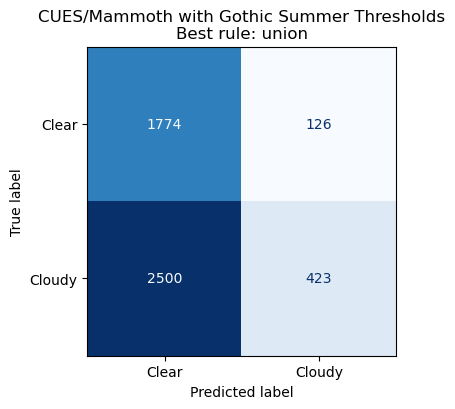

In [29]:
from pathlib import Path

# Apply Gothic summer thresholds to CUES/Mammoth Jun-Aug data.
summer_thr_path = Path(OUT_DIR) / 'gothic_rgb_band_thresholds_summer.csv'
if not summer_thr_path.exists():
    raise FileNotFoundError(f'Summer threshold file not found: {summer_thr_path}')

thr = pd.read_csv(summer_thr_path)
req = {'band', 'threshold', 'direction'}
if not req.issubset(set(thr.columns)):
    raise KeyError(f'Missing required columns in {summer_thr_path}: {sorted(req - set(thr.columns))}')

# Build threshold mapping.
thr_map = {row['band']: {'threshold': float(row['threshold']), 'direction': str(row['direction'])} for _, row in thr.iterrows()}
for b in ['red', 'green', 'blue']:
    if b not in thr_map:
        raise KeyError(f'Missing threshold for band: {b}')

cues_eval = pd.read_csv(MAMMOTH_CSV, parse_dates=['time'])
cues_eval['time'] = pd.to_datetime(cues_eval['time'], errors='coerce').astype('datetime64[ns]')
cues_eval = cues_eval[
    (cues_eval['time'] >= pd.Timestamp(WEEK_START))
    & (cues_eval['time'] < pd.Timestamp(WEEK_END))
].copy()
cues_eval = cues_eval.dropna(subset=['red', 'green', 'blue', 'cloud_binary']).copy()
cues_eval['cloud_binary'] = cues_eval['cloud_binary'].astype(int)

# Band votes using transferred Gothic-summer thresholds.
for band in ['red', 'green', 'blue']:
    t = thr_map[band]['threshold']
    d = thr_map[band]['direction']
    if d == '>':
        cues_eval[f'vote_{band}'] = (cues_eval[band] > t).astype(int)
    elif d == '<=':
        cues_eval[f'vote_{band}'] = (cues_eval[band] <= t).astype(int)
    else:
        raise ValueError(f'Unsupported direction for {band}: {d}')

votes = cues_eval[['vote_red', 'vote_green', 'vote_blue']].sum(axis=1)
cues_eval['pred_union'] = (votes >= 1).astype(int)
cues_eval['pred_majority'] = (votes >= 2).astype(int)
cues_eval['pred_intersection'] = (votes == 3).astype(int)

def _rule_metrics(y_true, y_pred):
    y_t = np.asarray(y_true, dtype=int)
    y_p = np.asarray(y_pred, dtype=int)

    tp = int(np.sum((y_p == 1) & (y_t == 1)))
    fn = int(np.sum((y_p == 0) & (y_t == 1)))
    tn = int(np.sum((y_p == 0) & (y_t == 0)))
    fp = int(np.sum((y_p == 1) & (y_t == 0)))

    clear_prec = tn / (tn + fn) if (tn + fn) else np.nan
    clear_rec = tn / (tn + fp) if (tn + fp) else np.nan
    cloudy_prec = tp / (tp + fp) if (tp + fp) else np.nan
    cloudy_rec = tp / (tp + fn) if (tp + fn) else np.nan

    return {
        'accuracy': float(accuracy_score(y_t, y_p)),
        'bal_acc': float(balanced_accuracy_score(y_t, y_p)),
        'clear_f1': float(f1_score(y_t, y_p, pos_label=0, zero_division=0)),
        'cloudy_f1': float(f1_score(y_t, y_p, pos_label=1, zero_division=0)),
        'macro_f1': float(f1_score(y_t, y_p, average='macro', zero_division=0)),
        'clear_prec': float(clear_prec) if pd.notna(clear_prec) else np.nan,
        'clear_rec': float(clear_rec) if pd.notna(clear_rec) else np.nan,
        'cloudy_prec': float(cloudy_prec) if pd.notna(cloudy_prec) else np.nan,
        'cloudy_rec': float(cloudy_rec) if pd.notna(cloudy_rec) else np.nan,
        'tn': tn,
        'fp': fp,
        'fn': fn,
        'tp': tp,
    }

rows = []
for rule, pred_col in [
    ('union', 'pred_union'),
    ('majority', 'pred_majority'),
    ('intersection', 'pred_intersection'),
]:
    m = _rule_metrics(cues_eval['cloud_binary'], cues_eval[pred_col])
    rows.append({
        'site': 'cues_mammoth',
        'rule': rule,
        'n': int(len(cues_eval)),
        'n_clear': int((cues_eval['cloud_binary'] == 0).sum()),
        'n_cloudy': int((cues_eval['cloud_binary'] == 1).sum()),
        **{k: (round(v, 3) if isinstance(v, float) and pd.notna(v) else v) for k, v in m.items()},
    })

transfer_df = pd.DataFrame(rows).sort_values('macro_f1', ascending=False).reset_index(drop=True)

out_metrics = Path(OUT_DIR) / 'mammoth_cues_gothic_summer_threshold_transfer_metrics.csv'
out_preds = Path(OUT_DIR) / 'mammoth_cues_gothic_summer_threshold_predictions.csv'
transfer_df.to_csv(out_metrics, index=False)
cues_eval.to_csv(out_preds, index=False)

print('Applied Gothic summer thresholds at CUES/Mammoth (Jun-Aug).')
print('\nThresholds used:')
print(thr[['band', 'threshold', 'direction']].to_string(index=False))
print('\nTransfer metrics by combining rule:')
print(transfer_df[['rule', 'accuracy', 'bal_acc', 'clear_f1', 'cloudy_f1', 'macro_f1', 'clear_prec', 'clear_rec', 'cloudy_prec', 'cloudy_rec', 'n', 'n_clear', 'n_cloudy']].to_string(index=False))
print(f'\nSaved: {out_metrics}')
print(f'Saved: {out_preds}')

best_rule = transfer_df.iloc[0]['rule']
cm = confusion_matrix(cues_eval['cloud_binary'].to_numpy(), cues_eval[f'pred_{best_rule}'].to_numpy(), labels=[0, 1])
fig, ax = plt.subplots(figsize=(4.8, 4.2))
ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Clear', 'Cloudy']).plot(
    ax=ax,
    cmap='Blues',
    colorbar=False,
    values_format='d',
)
ax.set_title(f'CUES/Mammoth with Gothic Summer Thresholds\nBest rule: {best_rule}')
plt.tight_layout()
plt.show()